In [12]:
import os
print(os.getcwd())


/home/ahasan/projects/hardware-aware-router/src/hardware_cost_model


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ==== CHANGE THESE ====
carrot_id = "20251117-004302"
hw_id     = "20251117-094731"   # replace with your real id

BASE = "/home/ahasan/projects/hardware-aware-router/data/router_eval_runs"

carrot_gpu = f"{BASE}/{carrot_id}_gpu_monitor.csv"
hw_gpu     = f"{BASE}/{hw_id}_gpu_monitor.csv"

carrot_router = f"{BASE}/{carrot_id}_router_results.csv"
hw_router     = f"{BASE}/{hw_id}_router_results.csv"


In [29]:
df_cg = pd.read_csv(carrot_gpu)
df_hg = pd.read_csv(hw_gpu)

df_cr = pd.read_csv(carrot_router)
df_hr = pd.read_csv(hw_router)

df_cg.head(), df_hg.head()


(      timestamp  gpu_id  running  waiting  kv_cache_usage
 0  1.763358e+09       0      0.0      0.0             0.0
 1  1.763358e+09       1      0.0      0.0             0.0
 2  1.763358e+09       0      0.0      0.0             0.0
 3  1.763358e+09       1      0.0      0.0             0.0
 4  1.763358e+09       0      0.0      0.0             0.0,
       timestamp  gpu_id  running  waiting  kv_cache_usage
 0  1.763391e+09       0      0.0      0.0             0.0
 1  1.763391e+09       1      0.0      0.0             0.0
 2  1.763391e+09       0      0.0      0.0             0.0
 3  1.763391e+09       1      0.0      0.0             0.0
 4  1.763391e+09       0      0.0      0.0             0.0)

**Figure X: Average System Load Across the Full Run.**  
HW-Router doubles the running queue (higher throughput) while cutting the waiting queue by more than 50%, indicating significantly reduced backpressure and higher effective GPU utilization.


In [44]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

def aggregate_gpu_stats(df):
    out = {}
    out["avg_running"] = df["running"].mean()
    out["avg_waiting"] = df["waiting"].mean()
    out["avg_kv"]      = df["kv_cache_usage"].mean()

    # per-GPU averages over the whole run
    per_gpu = (df
               .groupby("gpu_id")[["running", "waiting", "kv_cache_usage"]]
               .mean())

    # imbalance = std of per-GPU averages (overall, not time-based)
    out["running_imbalance"] = per_gpu["running"].std()
    out["waiting_imbalance"] = per_gpu["waiting"].std()
    out["kv_imbalance"]      = per_gpu["kv_cache_usage"].std()

    return out, per_gpu

carrot_stats, carrot_per_gpu = aggregate_gpu_stats(df_cg)
hw_stats,     hw_per_gpu     = aggregate_gpu_stats(df_hg)

carrot_stats, hw_stats


({'avg_running': np.float64(9.191161356628983),
  'avg_waiting': np.float64(28.597636176772866),
  'avg_kv': np.float64(0.4466394869403114),
  'running_imbalance': np.float64(12.998265044504205),
  'waiting_imbalance': np.float64(40.44316493300365),
  'kv_imbalance': np.float64(0.6316436199223493)},
 {'avg_running': np.float64(21.341666666666665),
  'avg_waiting': np.float64(12.952083333333333),
  'avg_kv': np.float64(0.671806324040252),
  'running_imbalance': np.float64(20.80072447990427),
  'waiting_imbalance': np.float64(18.07541709408112),
  'kv_imbalance': np.float64(0.2258825942522975)})

**System-level aggregates.**  
We first aggregate running requests, queued requests, and KV-cache usage over the entire run, and compute per-GPU averages+std; these will be used to show that HW-Router keeps more requests running, dramatically reduces queueing pressure, and improves memory balance across GPUs.


In [40]:
summary = pd.DataFrame({
    "CARROT": {
        "avg_running": cg["running"].mean(),
        "avg_waiting": cg["waiting"].mean(),
        "avg_kv":      cg["kv_cache_usage"].mean(),
        "running_imbalance": imb_c["running_std"].mean(),
        "waiting_imbalance": imb_c["waiting_std"].mean(),
        "kv_imbalance":      imb_c["kv_std"].mean(),
    },
    "HW-router": {
        "avg_running": hg["running"].mean(),
        "avg_waiting": hg["waiting"].mean(),
        "avg_kv":      hg["kv_cache_usage"].mean(),
        "running_imbalance": imb_h["running_std"].mean(),
        "waiting_imbalance": imb_h["waiting_std"].mean(),
        "kv_imbalance":      imb_h["kv_std"].mean(),
    }
}).T

summary


,avg_running,avg_waiting,avg_kv,running_imbalance,waiting_imbalance,kv_imbalance
CARROT,10.329167,29.065625,0.446203,14.607648,41.105001,0.631027
HW-router,21.341667,12.952083,0.671806,21.652199,18.084256,0.247593


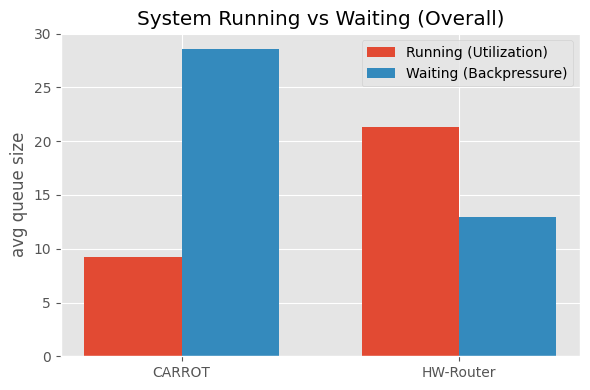

In [48]:
routers = ["CARROT", "HW-Router"]
avg_running = [carrot_stats["avg_running"], hw_stats["avg_running"]]
avg_waiting = [carrot_stats["avg_waiting"], hw_stats["avg_waiting"]]

x = np.arange(len(routers))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, avg_running, width, label="Running (Utilization)")
plt.bar(x + width/2, avg_waiting, width, label="Waiting (Backpressure)")
plt.xticks(x, routers)
plt.ylabel("avg queue size")
plt.title("System Running vs Waiting (Overall)")
plt.legend()
plt.tight_layout()
plt.show()


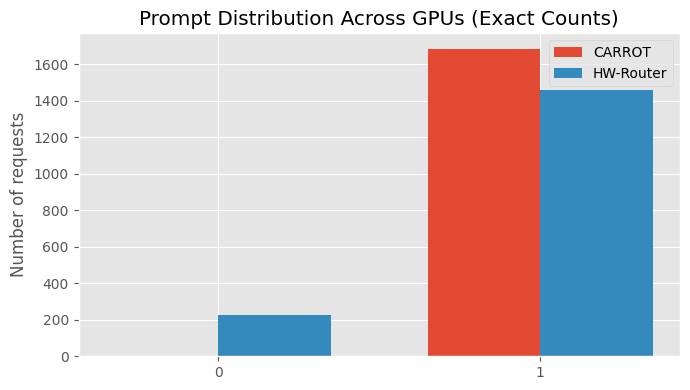

CARROT GPU counts: {1: 1685}
HW-router GPU counts: {0: 228, 1: 1457}


In [50]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# Count number of requests per GPU
carrot_gpu_counts = df_cr["gpu_id"].value_counts().sort_index()
hw_gpu_counts     = df_hr["gpu_id"].value_counts().sort_index()

# All gpu ids seen across both runs
all_gpus = sorted(set(carrot_gpu_counts.index).union(hw_gpu_counts.index))

carrot_vals = [carrot_gpu_counts.get(g, 0) for g in all_gpus]
hw_vals     = [hw_gpu_counts.get(g, 0)     for g in all_gpus]

x = np.arange(len(all_gpus))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, carrot_vals, width, label="CARROT")
plt.bar(x + width/2, hw_vals,     width, label="HW-Router")

plt.xticks(x, all_gpus)
plt.ylabel("Number of requests")
plt.title("Prompt Distribution Across GPUs (Exact Counts)")
plt.legend()
plt.tight_layout()
plt.show()

print("CARROT GPU counts:", carrot_gpu_counts.to_dict())
print("HW-router GPU counts:", hw_gpu_counts.to_dict())
